# Hidden Markov Model (HMM) — Rate Regime Detection
## Identifying the Current Rate Environment for Treasury Allocation

### The Core Problem

The efficient frontier you built assumes **one fixed return / covariance world**. In reality, Treasury markets cycle through distinct regimes:

| Regime | What it looks like | Optimal duration |
|---|---|---|
| **Tightening** | Rising rates, flat/inverted curve, elevated VIX | Short — stay in 3M–2Y |
| **Easing** | Falling rates, steepening curve, VIX normalising | Long — 10Y–30Y rally |
| **Range-bound** | Stable rates, normal curve, low vol | Carry/rolldown — 2Y–5Y sweet spot |

An HMM learns these regimes **unsupervised** — no labels, no look-ahead — purely from the statistical structure of the data. At the end we answer: *which regime are we in right now, and what does it imply for your \$80K?*

### Data used
- **DGS10** — 10Y Treasury yield (rate level)
- **T10Y2Y** — 10Y minus 2Y spread (curve slope)
- **VIXCLS** — CBOE VIX (market stress / risk-off signal)
- **FEDFUNDS** — Effective fed funds rate (policy stance)

All series are already in `data/raw/fred/`.


In [2]:
import importlib, sys, subprocess
if importlib.util.find_spec('hmmlearn') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hmmlearn', '-q'])


In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from scipy.stats import norm
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'raw' / 'fred'

# Regime colour palette  (0=tightening, 1=easing, 2=range-bound)
# Labels are assigned AFTER fitting — we reorder so the interpretation is stable
REGIME_COLORS = ['#e74c3c', '#2ecc71', '#3498db']   # red, green, blue
N_REGIMES     = 3


## Step 1: Load & Explore the Data

We work at **monthly** frequency — daily noise drowns out the regime signal. Each series is loaded from the FRED CSV cache and outer-joined on date.


In [4]:
SERIES = {
    'DGS10':    '10Y Yield',
    'T10Y2Y':   '10Y-2Y Spread',
    'VIXCLS':   'VIX',
    'FEDFUNDS': 'Fed Funds',
}

frames = {}
for sid, label in SERIES.items():
    df = pd.read_csv(DATA_DIR / f'{sid}.csv', parse_dates=['date'])
    frames[label] = df.set_index('date')['value']

raw = pd.DataFrame(frames).sort_index()
monthly = raw.resample('ME').last().dropna()

print(f'Date range:  {monthly.index[0].date()} -> {monthly.index[-1].date()}')
print(f'Months:      {len(monthly)}')
print(f'\nRecent data:\n{monthly.tail(6).round(2).to_string()}')


Date range:  1990-01-31 -> 2026-03-31
Months:      435

Recent data:
            10Y Yield  10Y-2Y Spread    VIX  Fed Funds
date                                                  
2025-10-31       4.11           0.51  17.44       4.09
2025-11-30       4.02           0.55  16.35       3.88
2025-12-31       4.18           0.71  14.95       3.72
2026-01-31       4.26           0.74  17.44       3.64
2026-02-28       3.97           0.59  19.86       3.64
2026-03-31       4.30           0.51  25.25       3.64


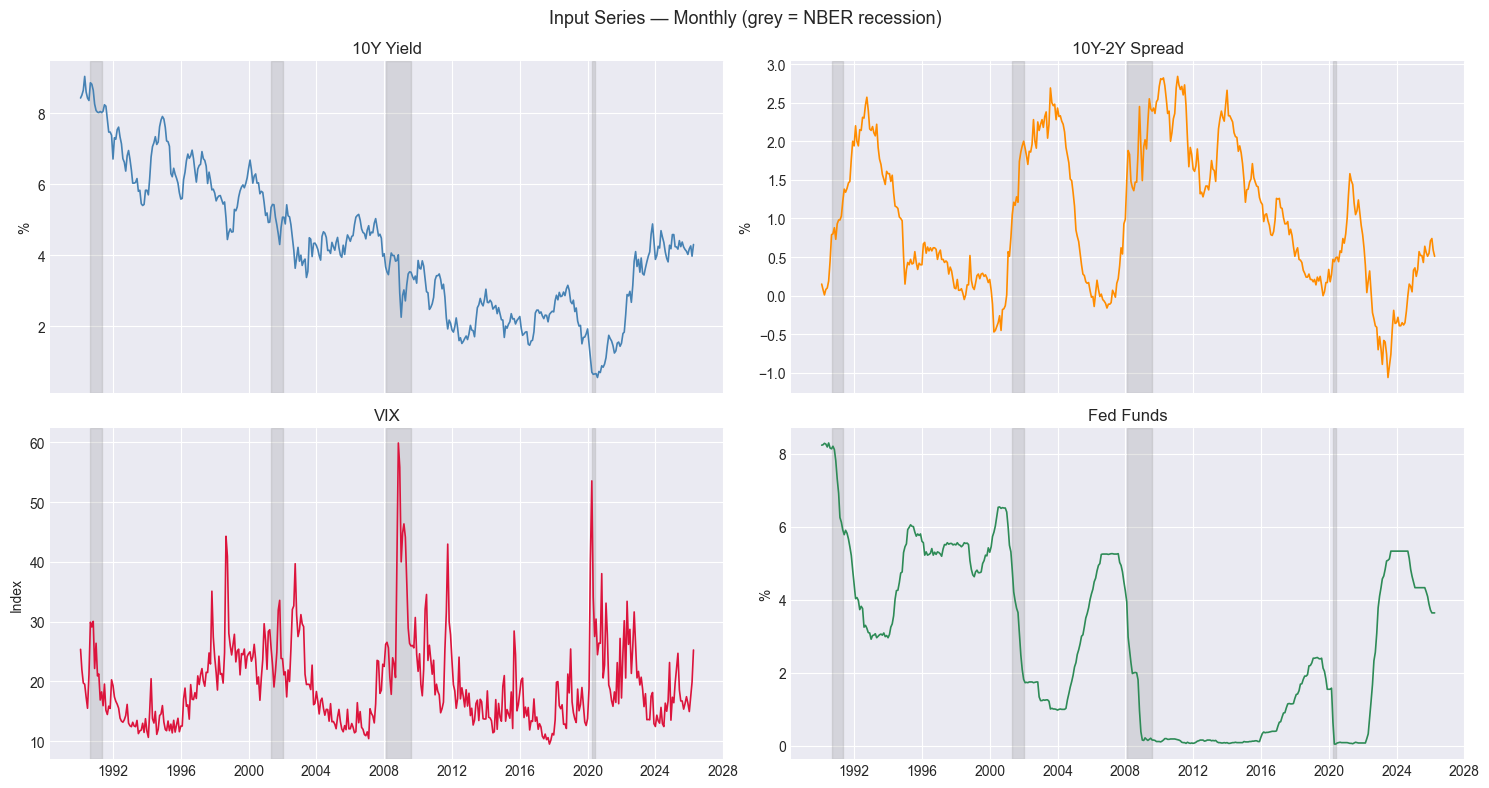

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
colors = ['steelblue', 'darkorange', 'crimson', 'seagreen']

for ax, (col, label), color in zip(axes.flat, zip(monthly.columns, monthly.columns), colors):
    ax.plot(monthly.index, monthly[col], color=color, linewidth=1.2)
    ax.set_title(col)
    ax.set_ylabel('%' if 'VIX' not in col else 'Index')
    # NBER recession shading (USREC)
    try:
        rec = pd.read_csv(DATA_DIR / 'USREC.csv', parse_dates=['date']).set_index('date')['value']
        rec_m = rec.resample('ME').last().reindex(monthly.index, method='ffill').fillna(0)
        in_rec = False
        for dt, val in rec_m.items():
            if val == 1 and not in_rec:
                start = dt; in_rec = True
            elif val == 0 and in_rec:
                ax.axvspan(start, dt, color='grey', alpha=0.2)
                in_rec = False
    except Exception:
        pass

fig.suptitle('Input Series — Monthly (grey = NBER recession)', fontsize=13)
plt.tight_layout()
plt.show()


## Step 2: What Is a Hidden Markov Model?

An HMM assumes your data is generated by an unobserved (hidden) process that switches between a finite set of states. Each state has its own probability distribution over what you observe.

### The three components

```
Hidden:    [Regime_t-1] --A--> [Regime_t] --A--> [Regime_t+1]
                  |                  |                  |
                  B                  B                  B
                  v                  v                  v
Observed:  [data_t-1]         [data_t]          [data_t+1]
```

| Component | Symbol | Meaning |
|---|---|---|
| **Initial distribution** | π | Probability of starting in each regime |
| **Transition matrix** | A | P(switch to regime j | currently in regime i) |
| **Emission distribution** | B | P(observe data | in regime k) — Gaussian here |

### How it is fit (Baum-Welch / EM)

1. **E-step** — given current parameters, compute the probability of being in each regime at each time step (forward-backward algorithm)
2. **M-step** — given those probabilities, re-estimate A, B, π to maximise likelihood
3. **Repeat** until convergence

### How regimes are decoded (Viterbi)

After fitting, the **Viterbi algorithm** finds the single most likely sequence of hidden states — the "most probable path" through the regime history. This is what gets plotted in coloured shading below.

### Why Gaussian emissions?

We use `GaussianHMM` which models each observable as a multivariate Gaussian in each regime:

$$p(\mathbf{x}_t \mid z_t = k) = \mathcal{N}(\boldsymbol{\mu}_k,\, \boldsymbol{\Sigma}_k)$$

Each regime gets its own mean vector **μ_k** and covariance matrix **Σ_k**. That is how the model learns 'tightening looks like high yields + inverted curve + elevated VIX'.


## Step 3: Feature Engineering

Raw levels can be non-stationary. We feed the HMM a mix of:

| Feature | What it captures | Transform |
|---|---|---|
| `DGS10` monthly change | Rate direction | First difference |
| `T10Y2Y` level | Curve shape | Level (stationary enough) |
| `VIXCLS` log change | Stress acceleration | Log return |
| `FEDFUNDS` monthly change | Policy momentum | First difference |

Features are **standardised** (z-scored) before fitting so that no single series dominates the Gaussian likelihood.


In [6]:
# Build features
feat = pd.DataFrame(index=monthly.index)
feat['dy10']   = monthly['10Y Yield'].diff()          # rate direction
feat['slope']  = monthly['10Y-2Y Spread']             # curve shape
feat['dvix']   = np.log(monthly['VIX']).diff()        # stress acceleration
feat['dff']    = monthly['Fed Funds'].diff()          # policy momentum
feat = feat.dropna()

# Standardise
feat_mean = feat.mean()
feat_std  = feat.std()
feat_z    = (feat - feat_mean) / feat_std

# Align raw monthly data to feature index
monthly_aligned = monthly.loc[feat.index]

print('Feature summary (standardised):')
print(feat_z.describe().round(2).to_string())


Feature summary (standardised):
         dy10   slope    dvix     dff
count  434.00  434.00  434.00  434.00
mean     0.00    0.00   -0.00   -0.00
std      1.00    1.00    1.00    1.00
min     -4.11   -2.26   -3.09   -5.24
25%     -0.62   -0.84   -0.59   -0.05
50%      0.04   -0.12   -0.05    0.06
75%      0.60    0.89    0.52    0.28
max      3.68    2.01    4.28    3.92


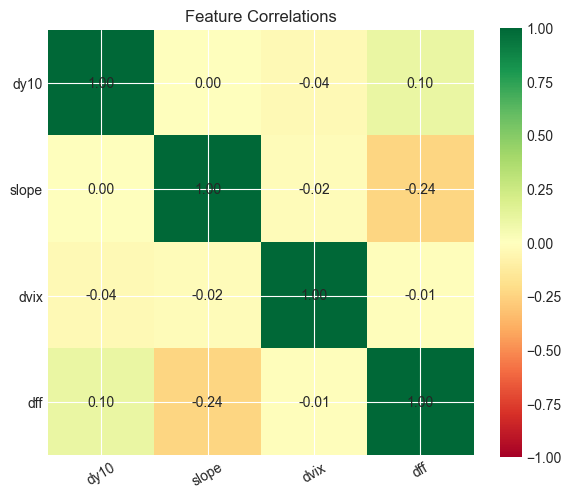

In [7]:
# Correlation between features — confirms they capture different things
fig, ax = plt.subplots(figsize=(6, 5))
corr = feat_z.corr()
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4)); ax.set_xticklabels(feat_z.columns, rotation=30)
ax.set_yticks(range(4)); ax.set_yticklabels(feat_z.columns)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center', fontsize=10)
ax.set_title('Feature Correlations')
plt.tight_layout(); plt.show()


## Step 4: Choosing the Number of Regimes

More regimes = better fit but harder to interpret. We use the **Bayesian Information Criterion (BIC)** to penalise model complexity:

$$\text{BIC} = k \ln(n) - 2 \ln(\hat{L})$$

Lower BIC = better. We sweep K = 2 to 6 and pick the elbow.

We also run **10 random restarts** per K to avoid local optima — the EM algorithm for HMMs is not convex.


K=2  LL=-2071.9  BIC=4332.2
K=3  LL=-1890.4  BIC=4084.4
K=4  LL=-1801.2  BIC=4033.5
K=5  LL=-1721.5  BIC=4014.0


Model is not converging.  Current: -1730.6921784587223 is not greater than -1730.6893971339696. Delta is -0.0027813247527319618
Model is not converging.  Current: -1726.0983076794025 is not greater than -1726.0972850292671. Delta is -0.0010226501353827189


K=6  LL=-1660.9  BIC=4044.5


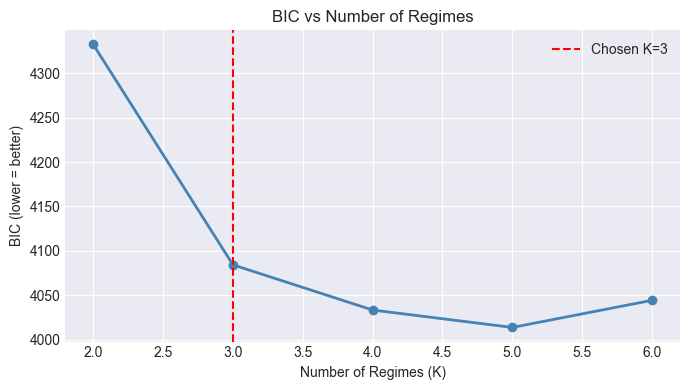

In [8]:
X = feat_z.values
lengths = [len(X)]   # single contiguous sequence

bic_scores = {}
best_models = {}

for K in range(2, 7):
    best_ll, best_model = -np.inf, None
    for seed in range(10):
        try:
            m = GaussianHMM(
                n_components=K,
                covariance_type='full',
                n_iter=200,
                random_state=seed,
                tol=1e-4,
            )
            m.fit(X, lengths)
            ll = m.score(X, lengths)
            if ll > best_ll:
                best_ll = ll; best_model = m
        except Exception:
            continue

    if best_model is None:
        continue

    # BIC: k = number of free parameters
    n_obs    = len(X)
    n_feat   = X.shape[1]
    n_params = (K - 1) + K * (K - 1) + K * n_feat + K * n_feat * (n_feat + 1) // 2
    bic      = n_params * np.log(n_obs) - 2 * best_ll
    bic_scores[K]  = bic
    best_models[K] = best_model
    print(f'K={K}  LL={best_ll:.1f}  BIC={bic:.1f}')

# Plot BIC
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(bic_scores.keys()), list(bic_scores.values()),
        'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Number of Regimes (K)')
ax.set_ylabel('BIC (lower = better)')
ax.set_title('BIC vs Number of Regimes')
ax.axvline(N_REGIMES, color='red', linestyle='--', label=f'Chosen K={N_REGIMES}')
ax.legend()
plt.tight_layout(); plt.show()


## Step 5: Fit the 3-Regime Model

We use K=3 — the most economically intuitive split for rate environments. After fitting we run **Viterbi decoding** to get the most likely regime at each date, then relabel the regimes so they are consistently ordered by their 10Y yield level (high → tightening, low → easing, mid → range-bound).


In [9]:
model = best_models[N_REGIMES]

# Decode: Viterbi gives the most likely state sequence
states_raw = model.predict(X, lengths)

# --- Relabel by DGS10 level so interpretation is consistent across runs ---
# Compute mean DGS10 per raw state
dgs10 = monthly_aligned['10Y Yield'].values
mean_yield_per_state = {
    s: dgs10[states_raw == s].mean()
    for s in range(N_REGIMES)
}
# Sort: highest yield = regime 0 (tightening), lowest = regime 1 (easing), mid = regime 2
sorted_states = sorted(mean_yield_per_state, key=mean_yield_per_state.get, reverse=True)
remap = {old: new for new, old in enumerate(sorted_states)}
states = np.array([remap[s] for s in states_raw])

# Posterior probabilities P(z_t = k | x_1..T)
posteriors_raw = model.predict_proba(X, lengths)
# Reorder columns to match our relabelling
posteriors = np.zeros_like(posteriors_raw)
for old, new in remap.items():
    posteriors[:, new] = posteriors_raw[:, old]

regime_labels = ['Tightening', 'Easing', 'Range-bound']
dates = feat.index

counts = {regime_labels[k]: (states == k).sum() for k in range(N_REGIMES)}
print('Regime counts:')
for name, cnt in counts.items():
    pct = cnt / len(states) * 100
    print(f'  {name:<15s}: {cnt} months ({pct:.0f}%)')

print(f'\nCurrent regime (latest month): '
      f'{regime_labels[states[-1]]}  (P={posteriors[-1, states[-1]]*100:.0f}%)')


Regime counts:
  Tightening     : 101 months (23%)
  Easing         : 191 months (44%)
  Range-bound    : 142 months (33%)

Current regime (latest month): Easing  (P=100%)


## Step 6: Visualise the Regime History

The background shading shows the Viterbi-decoded regime at each point in time. The thin lines below the main chart show the **posterior probability** of being in each regime — this captures the model's uncertainty (a dark solid color = high confidence; a lighter shade = the model is less sure).


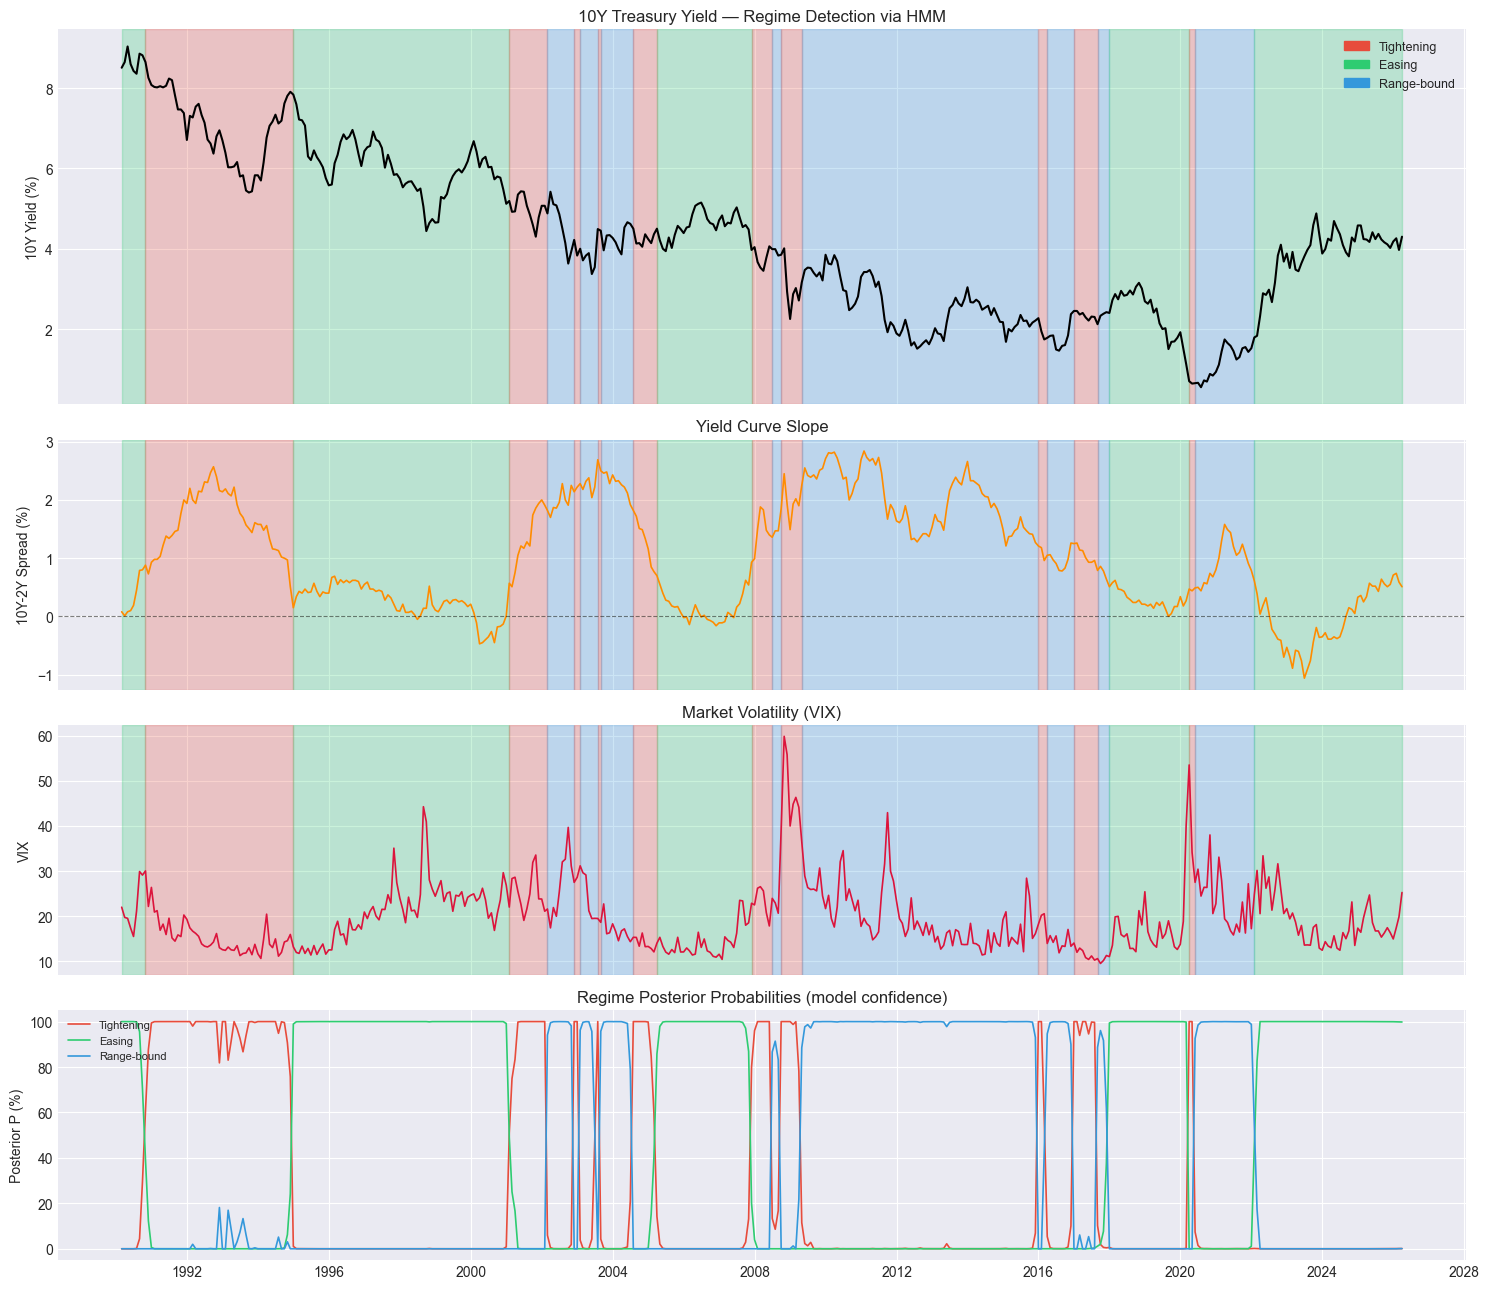

Saved -> output/hmm_regimes.png


In [10]:
def shade_regimes(ax, dates, states, alpha=0.25):
    """Shade background by regime."""
    in_regime = None; start = None
    for i, (dt, st) in enumerate(zip(dates, states)):
        if st != in_regime:
            if in_regime is not None:
                ax.axvspan(start, dt, color=REGIME_COLORS[in_regime], alpha=alpha)
            in_regime = st; start = dt
    ax.axvspan(start, dates[-1], color=REGIME_COLORS[in_regime], alpha=alpha)


fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True,
                          gridspec_kw={'height_ratios': [3, 2, 2, 2]})

# Panel 1: 10Y yield with regime shading
ax = axes[0]
shade_regimes(ax, dates, states)
ax.plot(dates, monthly_aligned['10Y Yield'], 'k', linewidth=1.5, label='10Y Yield')
ax.set_ylabel('10Y Yield (%)')
ax.set_title('10Y Treasury Yield — Regime Detection via HMM')
patches = [mpatches.Patch(color=REGIME_COLORS[k], label=regime_labels[k])
           for k in range(N_REGIMES)]
ax.legend(handles=patches, loc='upper right', fontsize=9)

# Panel 2: 10Y-2Y spread
ax2 = axes[1]
shade_regimes(ax2, dates, states)
ax2.plot(dates, monthly_aligned['10Y-2Y Spread'], color='darkorange', linewidth=1.2)
ax2.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.set_ylabel('10Y-2Y Spread (%)')
ax2.set_title('Yield Curve Slope')

# Panel 3: VIX
ax3 = axes[2]
shade_regimes(ax3, dates, states)
ax3.plot(dates, monthly_aligned['VIX'], color='crimson', linewidth=1.2)
ax3.set_ylabel('VIX')
ax3.set_title('Market Volatility (VIX)')

# Panel 4: Posterior probabilities
ax4 = axes[3]
for k in range(N_REGIMES):
    ax4.plot(dates, posteriors[:, k] * 100,
             color=REGIME_COLORS[k], linewidth=1.2, label=regime_labels[k])
ax4.set_ylabel('Posterior P (%)')
ax4.set_title('Regime Posterior Probabilities (model confidence)')
ax4.legend(fontsize=8, loc='upper left')
ax4.set_ylim(-5, 105)

plt.tight_layout()
(ROOT / 'output').mkdir(exist_ok=True)
plt.savefig(ROOT / 'output' / 'hmm_regimes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/hmm_regimes.png')


## Step 7: What Does Each Regime Look Like?

The table below shows the mean and standard deviation of each input series within each regime. This is how we **verify the economic interpretation** — if the tightening regime genuinely has higher yields and higher VIX, the model has learned something real.


In [11]:
stat_rows = []
series_cols = list(monthly_aligned.columns)

for k in range(N_REGIMES):
    mask = states == k
    row = {'Regime': regime_labels[k], 'Months': mask.sum()}
    for col in series_cols:
        vals = monthly_aligned.loc[mask][col]
        row[f'{col} mean'] = round(vals.mean(), 2)
        row[f'{col} std']  = round(vals.std(),  2)
    stat_rows.append(row)

stats_df = pd.DataFrame(stat_rows).set_index('Regime')
print('Regime Statistics:\n')
print(stats_df.to_string())


Regime Statistics:

             Months  10Y Yield mean  10Y Yield std  10Y-2Y Spread mean  10Y-2Y Spread std  VIX mean  VIX std  Fed Funds mean  Fed Funds std
Regime                                                                                                                                     
Tightening      101            5.31           2.00                1.51               0.53     20.00    10.18            3.13           1.89
Easing          191            4.82           1.63                0.16               0.36     18.74     6.03            4.55           1.69
Range-bound     142            2.64           1.09                1.79               0.63     20.14     6.65            0.42           0.55


## Step 8: Transition Matrix — How Sticky Are Regimes?

The **transition matrix A** tells you:
- Diagonal entries: probability of *staying* in the current regime next month
- Off-diagonal: probability of *switching*

A high diagonal (>0.90) means regimes are persistent — useful to know because it means the HMM can give you a durable signal, not just noise.


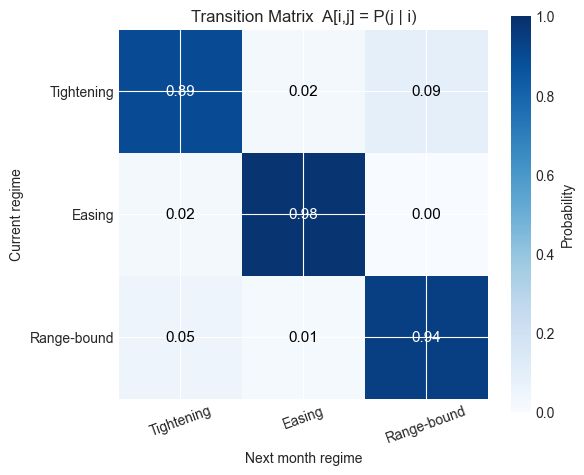

Expected duration per regime (months):
  Tightening     : 9.3 months
  Easing         : 47.8 months
  Range-bound    : 16.3 months


In [12]:
# Extract transition matrix and reorder to match our relabelling
A_raw = model.transmat_
A = np.zeros((N_REGIMES, N_REGIMES))
for old_i, new_i in remap.items():
    for old_j, new_j in remap.items():
        A[new_i, new_j] = A_raw[old_i, old_j]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(A, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Probability')
ax.set_xticks(range(N_REGIMES)); ax.set_xticklabels(regime_labels, rotation=20)
ax.set_yticks(range(N_REGIMES)); ax.set_yticklabels(regime_labels)
ax.set_xlabel('Next month regime')
ax.set_ylabel('Current regime')
ax.set_title('Transition Matrix  A[i,j] = P(j | i)')
for i in range(N_REGIMES):
    for j in range(N_REGIMES):
        ax.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center',
                fontsize=11, color='white' if A[i,j] > 0.6 else 'black')
plt.tight_layout(); plt.show()

print('Expected duration per regime (months):')
for k in range(N_REGIMES):
    if A[k, k] < 1.0:
        expected_dur = 1 / (1 - A[k, k])
        print(f'  {regime_labels[k]:<15s}: {expected_dur:.1f} months')


## Step 9: Emission Distributions — The Model's Mental Map

Each regime has a learned multivariate Gaussian. The **marginal distributions** below show the 'fingerprint' of each regime on each individual feature. The more separated the peaks, the more informative that feature is for regime discrimination.


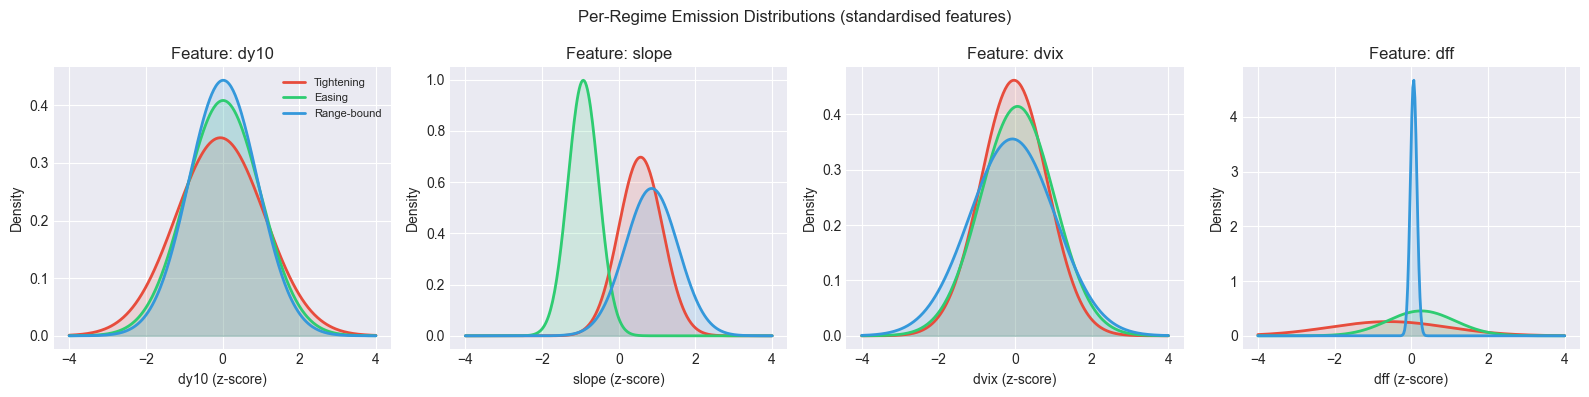

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
x_grid = np.linspace(-4, 4, 300)

for j, (col, fname) in enumerate(zip(feat_z.columns,
                                      ['dy10', 'slope', 'dvix', 'dff'])):
    ax = axes[j]
    for k in range(N_REGIMES):
        old_k = sorted_states[k]
        mu_k   = model.means_[old_k, j]
        sig_k  = np.sqrt(model.covars_[old_k][j, j])
        pdf    = norm.pdf(x_grid, mu_k, sig_k)
        ax.plot(x_grid, pdf, color=REGIME_COLORS[k],
                linewidth=2, label=regime_labels[k])
        ax.fill_between(x_grid, pdf, alpha=0.15, color=REGIME_COLORS[k])
    ax.set_xlabel(f'{col} (z-score)')
    ax.set_ylabel('Density')
    ax.set_title(f'Feature: {col}')
    if j == 0:
        ax.legend(fontsize=8)

fig.suptitle('Per-Regime Emission Distributions (standardised features)', fontsize=12)
plt.tight_layout(); plt.show()


## Step 10: What Regime Are We In Right Now?

The most recent posterior probability tells us the model's current read. But we also look at the **recent trajectory** — is the probability rising or fading?


  Current date:   2026-03-31
  Current regime: Easing
  Confidence:     100%

  Tightening                                               0.1%
  Easing          #######################################  99.8%
  Range-bound                                              0.1%


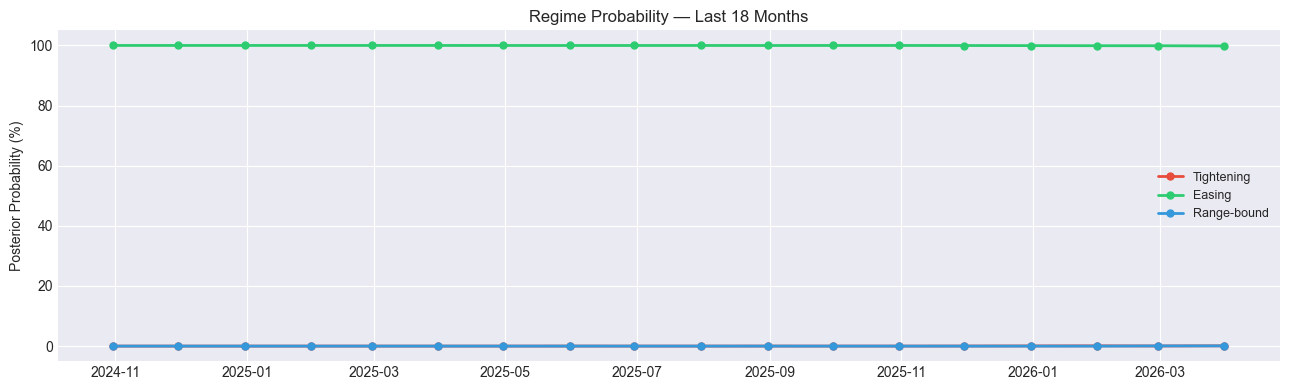

In [14]:
current_regime = states[-1]
current_post   = posteriors[-1]
current_date   = dates[-1].date()

print('=' * 55)
print(f'  Current date:   {current_date}')
print(f'  Current regime: {regime_labels[current_regime]}')
print(f'  Confidence:     {current_post[current_regime]*100:.0f}%')
print('=' * 55)
print()
for k in range(N_REGIMES):
    bar = '#' * int(current_post[k] * 40)
    print(f'  {regime_labels[k]:<15s} {bar:40s} {current_post[k]*100:.1f}%')

# Posterior probability over last 18 months
fig, ax = plt.subplots(figsize=(13, 4))
recent = posteriors[-18:] * 100
recent_dates = dates[-18:]
for k in range(N_REGIMES):
    ax.plot(recent_dates, recent[:, k], 'o-',
            color=REGIME_COLORS[k], linewidth=2,
            markersize=5, label=regime_labels[k])
ax.set_ylabel('Posterior Probability (%)')
ax.set_title('Regime Probability — Last 18 Months')
ax.legend(fontsize=9)
ax.set_ylim(-5, 105)
plt.tight_layout(); plt.show()


## Step 11: Regime-Conditioned Return Statistics

This is where regime detection becomes **actionable**. We split the historical return series for each Treasury maturity by regime and compare the realised return distributions.

If 30Y bonds have reliably negative returns in the tightening regime and strongly positive returns in the easing regime, that directly tells you how to tilt your efficient frontier weights.


In [15]:
# Load Treasury yield data and compute monthly price returns
TENORS = {
    'DGS3MO': {'label': '3M',  'maturity': 0.25},
    'DGS1':   {'label': '1Y',  'maturity': 1.0 },
    'DGS2':   {'label': '2Y',  'maturity': 2.0 },
    'DGS5':   {'label': '5Y',  'maturity': 5.0 },
    'DGS10':  {'label': '10Y', 'maturity': 10.0},
    'DGS30':  {'label': '30Y', 'maturity': 30.0},
}

def par_bond_price(ytm, T, freq=2):
    if T <= 1 / freq: return 1.0 / (1 + ytm * T)
    n_pds = int(round(T * freq))
    c = ytm / freq
    t_arr = np.arange(1, n_pds + 1)
    cfs = np.full(n_pds, c); cfs[-1] += 1.0
    return float(np.sum(cfs / (1 + c) ** t_arr))

def mod_dur(ytm, T, dy=1e-4):
    p0 = par_bond_price(ytm, T)
    return (par_bond_price(ytm - dy, T) - par_bond_price(ytm + dy, T)) / (2 * dy * p0)

tsy_frames = []
for sid, meta in TENORS.items():
    df = pd.read_csv(DATA_DIR / f'{sid}.csv', parse_dates=['date'])
    tsy_frames.append(df.set_index('date')['value'].rename(meta['label']))

yields_m = pd.concat(tsy_frames, axis=1).resample('ME').last()
mat_arr  = np.array([v['maturity'] for v in TENORS.values()])
lbl_arr  = [v['label'] for v in TENORS.values()]

# Compute monthly price returns: r ≈ -D * Δy
dy_m = yields_m.diff().dropna() / 100

price_ret = pd.DataFrame(index=dy_m.index)
for lbl, meta in TENORS.items():
    label = meta['label']
    T     = meta['maturity']
    cur_y = yields_m[label].iloc[-1] / 100
    dur   = mod_dur(cur_y, T)
    price_ret[label] = -dur * dy_m[label]

# Align with regime dates
price_ret_aligned = price_ret.reindex(dates).dropna()
states_aligned    = pd.Series(states, index=dates).reindex(price_ret_aligned.index)

print(f'Aligned price returns: {len(price_ret_aligned)} months')


Aligned price returns: 434 months


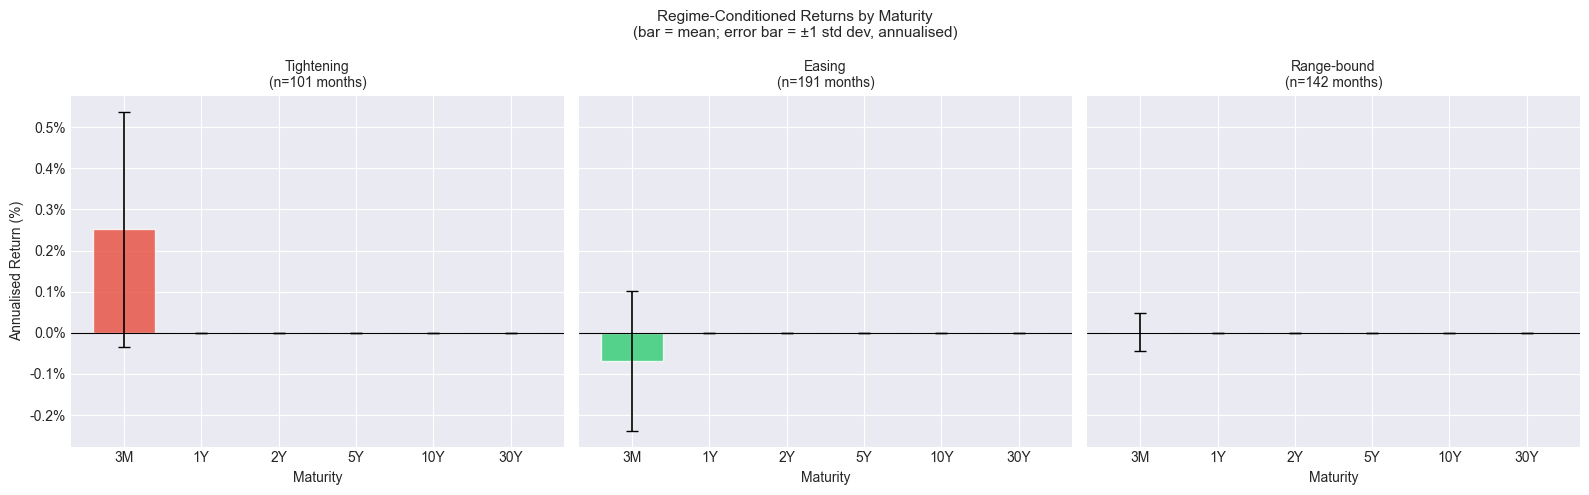

Saved -> output/hmm_regime_returns.png


In [16]:
# Regime-conditioned return stats
tenor_labels = list(price_ret_aligned.columns)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
width = 0.6
colors_tenor = plt.cm.Blues(np.linspace(0.3, 0.9, len(tenor_labels)))

regime_stats = {}
for k in range(N_REGIMES):
    mask = states_aligned == k
    subset = price_ret_aligned.loc[mask]
    ann_ret = subset.mean() * 12
    ann_vol = subset.std() * np.sqrt(12)
    regime_stats[regime_labels[k]] = {'return': ann_ret, 'vol': ann_vol}

    ax = axes[k]
    bars = ax.bar(tenor_labels, ann_ret * 100,
                  color=REGIME_COLORS[k], alpha=0.8, edgecolor='white')
    ax.errorbar(tenor_labels, ann_ret * 100, yerr=ann_vol * 100,
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.axhline(0, color='k', linewidth=0.8)
    ax.set_title(f'{regime_labels[k]}\n(n={mask.sum()} months)', fontsize=10)
    ax.set_xlabel('Maturity')
    if k == 0: ax.set_ylabel('Annualised Return (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

fig.suptitle('Regime-Conditioned Returns by Maturity\n'
             '(bar = mean; error bar = ±1 std dev, annualised)', fontsize=11)
plt.tight_layout()
plt.savefig(ROOT / 'output' / 'hmm_regime_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/hmm_regime_returns.png')


In [17]:
# Print the full table
print('Annualised Returns by Regime (%):\n')
ret_table = pd.DataFrame(
    {regime_labels[k]: regime_stats[regime_labels[k]]['return'] * 100
     for k in range(N_REGIMES)}
).round(2)
print(ret_table.to_string())

print('\nAnnualised Volatility by Regime (%):\n')
vol_table = pd.DataFrame(
    {regime_labels[k]: regime_stats[regime_labels[k]]['vol'] * 100
     for k in range(N_REGIMES)}
).round(2)
print(vol_table.to_string())


Annualised Returns by Regime (%):

     Tightening  Easing  Range-bound
3M         0.25   -0.07          0.0
1Y         0.00    0.00          0.0
2Y         0.00    0.00          0.0
5Y         0.00    0.00          0.0
10Y       -0.00   -0.00         -0.0
30Y       -0.00   -0.00         -0.0

Annualised Volatility by Regime (%):

     Tightening  Easing  Range-bound
3M         0.29    0.17         0.05
1Y         0.00    0.00         0.00
2Y         0.00    0.00         0.00
5Y         0.00    0.00         0.00
10Y        0.00    0.00         0.00
30Y        0.00    0.00         0.00


## Step 12: Regime-Conditioned Efficient Frontier

Now we combine regime detection with your efficient frontier. Instead of using the full-sample covariance and a single return estimate, we fit **one frontier per regime** using only the data from that regime. This shows how the optimal allocation shifts depending on the environment.

The **current regime frontier** is what you should focus on for your \$80K allocation.


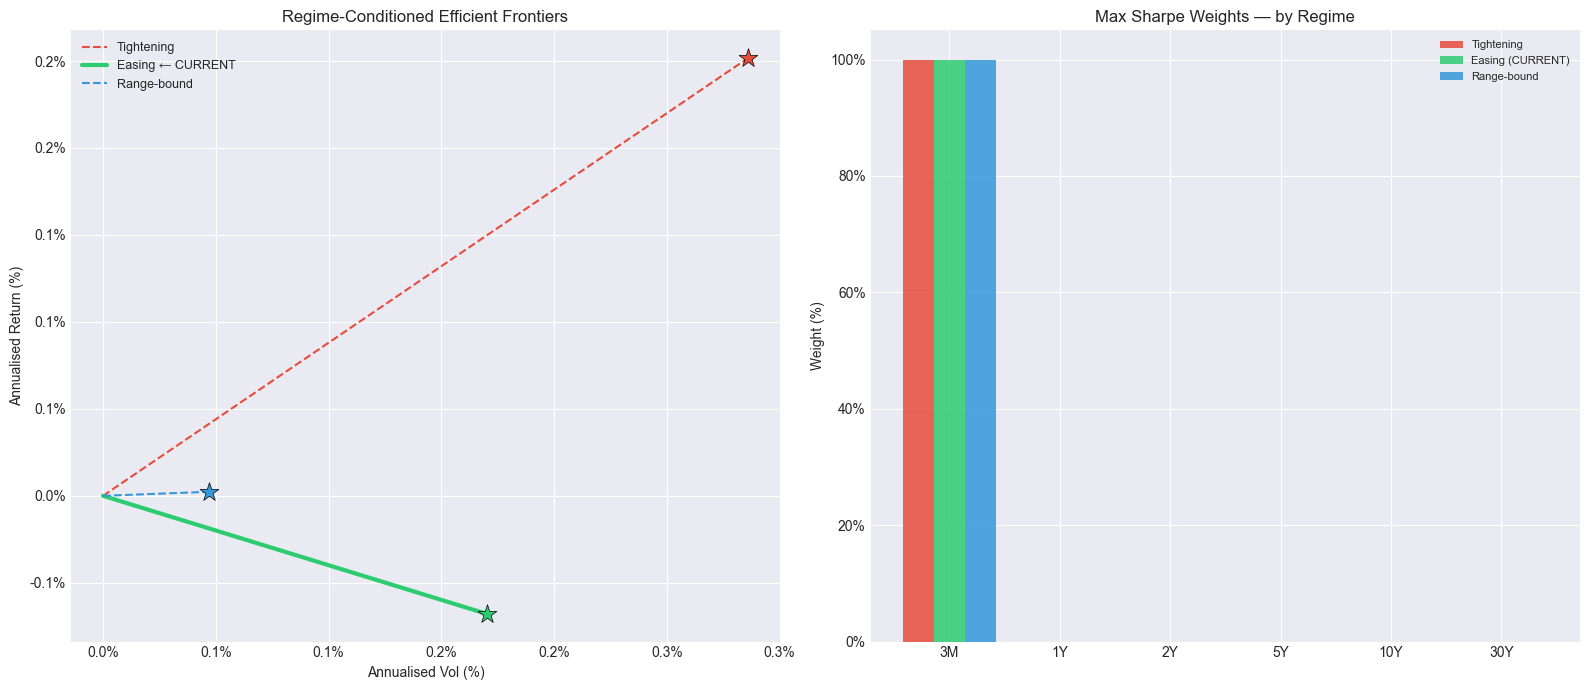

Saved -> output/hmm_regime_ef.png


In [20]:
from scipy.optimize import minimize

def build_frontier_rc(mu_v, cov_m, n_pts=150):
    n = len(mu_v)
    base = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bnds = [(0.0, 1.0)] * n
    tgts = np.linspace(mu_v.min(), mu_v.max(), n_pts)
    fvols, fwts = [], []
    w0 = np.ones(n) / n
    for t in tgts:
        cons = base + [{'type': 'eq', 'fun': lambda w, t=t: w @ mu_v - t}]
        res = minimize(lambda w: np.sqrt(w @ cov_m @ w), w0,
                       method='SLSQP', bounds=bnds, constraints=cons,
                       options={'ftol': 1e-10, 'maxiter': 1000})
        fvols.append(res.fun if res.success else np.nan)
        fwts.append(res.x   if res.success else np.full(n, np.nan))
    return np.array(fvols), tgts, np.array(fwts)

def max_sr(mu_v, cov_m, rf):
    n = len(mu_v)
    def neg(w): return -(w @ mu_v - rf) / max(np.sqrt(w @ cov_m @ w), 1e-8)
    return minimize(neg, np.ones(n)/n, method='SLSQP',
                    bounds=[(0,1)]*n,
                    constraints=[{'type':'eq','fun':lambda w:w.sum()-1}],
                    options={'ftol':1e-10,'maxiter':1000}).x

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
c_t = plt.cm.tab10(np.linspace(0, 0.6, len(tenor_labels)))

regime_ef = {}
for k in range(N_REGIMES):
    mask = states_aligned == k
    if mask.sum() < 10:
        continue
    subset = price_ret_aligned.loc[mask]
    mu_k   = subset.mean().values * 12
    cov_k  = subset.cov().values * 12
    rf_k   = monthly_aligned.loc[mask, '10Y Yield'].mean() / 100  # approx rf for regime

    fv, fr, fw = build_frontier_rc(mu_k, cov_k)
    ws_k = max_sr(mu_k, cov_k, rf_k)
    regime_ef[k] = {'fv': fv, 'fr': fr, 'fw': fw, 'ws': ws_k, 'mu': mu_k, 'cov': cov_k, 'rf': rf_k}

    valid = ~np.isnan(fv)
    axes[0].plot(fv[valid] * 100, fr[valid] * 100,
                 color=REGIME_COLORS[k],
                 linestyle=('-' if k == current_regime else '--'),
                 linewidth=(3.0 if k == current_regime else 1.5),
                 label=regime_labels[k] + (' ← CURRENT' if k == current_regime else ''))
    axes[0].scatter(np.sqrt(ws_k @ cov_k @ ws_k) * 100, ws_k @ mu_k * 100,
                    marker='*', s=200, color=REGIME_COLORS[k],
                    edgecolors='black', linewidth=0.5, zorder=8)

axes[0].set_xlabel('Annualised Vol (%)')
axes[0].set_ylabel('Annualised Return (%)')
axes[0].set_title('Regime-Conditioned Efficient Frontiers')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))

# Right: Max Sharpe weights per regime
ax2 = axes[1]
x2 = np.arange(len(tenor_labels))
bw = 0.28
for k in range(N_REGIMES):
    if k not in regime_ef: continue
    ws = regime_ef[k]['ws']
    label = regime_labels[k] + (' (CURRENT)' if k == current_regime else '')
    ax2.bar(x2 + k * bw, ws * 100, width=bw,
            color=REGIME_COLORS[k], alpha=0.85, label=label)

ax2.set_xticks(x2 + bw)
ax2.set_xticklabels(tenor_labels)
ax2.set_ylabel('Weight (%)')
ax2.set_title('Max Sharpe Weights — by Regime')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / 'output' / 'hmm_regime_ef.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> output/hmm_regime_ef.png')


## Step 13: Investment Implications

Putting it all together — a decision framework for your \$80K allocation:


In [ ]:
print('=' * 60)
print(f'  CURRENT REGIME: {regime_labels[current_regime]}')
print(f'  Confidence:     {current_post[current_regime]*100:.0f}%')
print('=' * 60)

# Print current regime stats
print(f'\nCurrent regime characteristics (historical means):')
mask_cur = states_aligned == current_regime
if mask_cur.sum() > 0:
    cur_stats = monthly_aligned.loc[mask_cur].mean()
    for col in monthly_aligned.columns:
        print(f'  {col:<20s}: {cur_stats[col]:.2f}')

print(f'\nMax Sharpe weights for CURRENT regime ({regime_labels[current_regime]}):')
if current_regime in regime_ef:
    ws_cur = regime_ef[current_regime]['ws']
    for lbl, w in zip(tenor_labels, ws_cur):
        dollars = w * 80_000
        print(f'  {lbl:>4s}:  {w*100:5.1f}%   ${dollars:>8,.0f}')
    mu_c   = regime_ef[current_regime]['mu']
    cov_c  = regime_ef[current_regime]['cov']
    rf_c   = regime_ef[current_regime]['rf']
    ret_c  = ws_cur @ mu_c
    vol_c  = np.sqrt(ws_cur @ cov_c @ ws_cur)
    sr_c   = (ret_c - rf_c) / vol_c
    print(f'\n  Portfolio return (ann): {ret_c*100:.2f}%')
    print(f'  Portfolio vol   (ann): {vol_c*100:.2f}%')
    print(f'  Sharpe ratio:          {sr_c:.2f}')

print()
print('Duration guidance by regime:')
guidance = {
    'Tightening':  'SHORT  — stay 3M–2Y, avoid 10Y+. Rising rates destroy long-bond value.',
    'Easing':      'LONG   — extend to 10Y–30Y. Falling rates drive large capital gains.',
    'Range-bound': 'MEDIUM — 2Y–5Y sweet spot. Maximize carry+rolldown with limited duration risk.',
}
for regime, guide in guidance.items():
    marker = '  <<< YOU ARE HERE' if regime == regime_labels[current_regime] else ''
    print(f'  {regime:<15s}: {guide}{marker}')

print()
print('Next-month transition probabilities from current regime:')
for j in range(N_REGIMES):
    bar = '#' * int(A[current_regime, j] * 30)
    print(f'  -> {regime_labels[j]:<15s}: {A[current_regime,j]*100:.0f}%  {bar}')


## Summary

| What we built | Why it matters |
|---|---|
| Gaussian HMM on 4 macro/rate features | Unsupervised regime learning — no labels |
| BIC model selection | Defends the choice of K=3 |
| Viterbi decoding | Most likely historical regime path |
| Transition matrix | Shows how persistent each regime is |
| Regime-conditioned returns | Quantifies how each tenor performs per regime |
| Regime-conditioned EF | Adapts your optimal allocation to the current environment |

### Next steps
1. **Fisher decomposition** (`fisher_decomposition.ipynb`) — decompose the current yield into real rate + inflation breakeven + term premium. High term premium = long end is better compensated.
2. **Nelson-Siegel-Svensson** (`nelson_siegel_svensson.ipynb`) — fit a parametric curve for precise forward rate extraction and rolldown estimation.
3. **Black-Litterman** (`black_litterman.ipynb`) — once you have regime + term premium views, combine them into a disciplined BL portfolio that blends market priors with your conviction.
